# 01 · 认识输入、观测单位与缺失

**运行目标：** 核对记录粒度、字段和六级分布。

**输入：** 固定种子合成样本，24名合成学生、192条提问。

**可调整：** 修改 synthetic_records(seed=26) 的种子；改变样本规模时同步调整数量检查。

In [1]:
from pathlib import Path
import sys, json

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "aiv").is_dir())
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
from aiv.data import synthetic_records

records = synthetic_records(seed=26)
LIVE_API = False  # Explicit opt-in only. Default cells never spend credits.
from aiv.notebook_materials import configure_style, save_figure
configure_style()

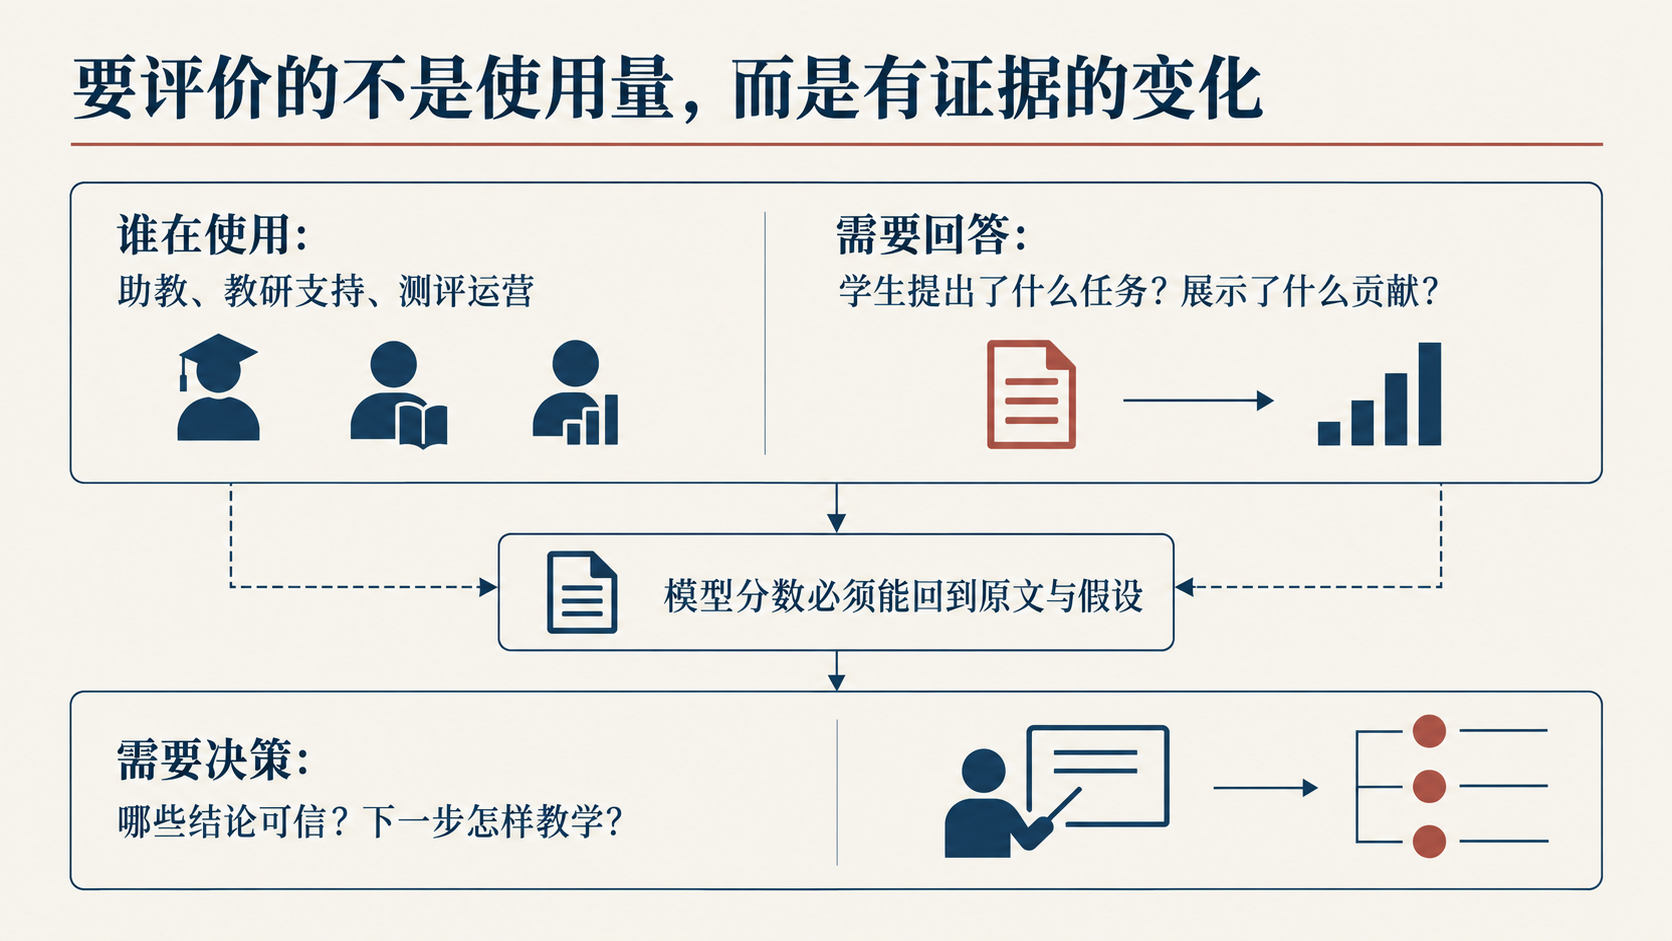

路演02｜先区分评价对象，再决定需要哪些输入。

In [2]:
from IPython.display import Image, Markdown, display
reference_path = ROOT / 'slides/roadshow/images/02.png'
if reference_path.is_file():
    display(Image(filename=str(reference_path), width=960))
    display(Markdown('路演02｜先区分评价对象，再决定需要哪些输入。'))
else:
    display(Markdown('配图未附于本地副本：`' + reference_path.name + '`。可继续执行下方计算。'))

## 数据字典与粒度

In [3]:
frame = pd.DataFrame(records)
display(frame[["student", "timestamp", "question", "agent", "label"]].head(6))
display(
    pd.DataFrame(
        {
            "field": ["student", "label", "session", "agent"],
            "meaning": [
                "合成学生编号",
                "构造任务层级 1–6",
                "已知合成会话边界",
                "合成工具类型",
            ],
        }
    )
)

,student,timestamp,question,agent,label
0,S001,2026-01-01,我提出一个新方案：先按成本分层抽样，再用残差校正标签，最后用模拟检验覆盖率。请质疑我的设计。,逆行侠,6
1,S001,2026-01-02,我比较了两种假设：固定需求忽略了季节性，随机需求会改变库存约束，请分析影响。,探知侠,4
2,S001,2026-01-03,我把每件产品的成本代入约束，得到 2x+3y≤120，请检查代入过程。,探知侠,3
3,S001,2026-01-04,我把每件产品的成本代入约束，得到 2x+3y≤120，请检查代入过程。,数模全才,3
4,S001,2026-01-05,模型假设观测独立，但同一个学生有多次记录。我认为标准误偏小，应按学生聚类，你怎么看？,数模匹配,5
5,S001,2026-01-06,我把每件产品的成本代入约束，得到 2x+3y≤120，请检查代入过程。,数模全才,3


,field,meaning
0,student,合成学生编号
1,label,构造任务层级 1–6
2,session,已知合成会话边界
3,agent,合成工具类型


一行是一次提问；任务要求层级不等于学生掌握程度。合成会话边界已知，真实 CSV 缺失边界时不能直接串联。

## 检查分布

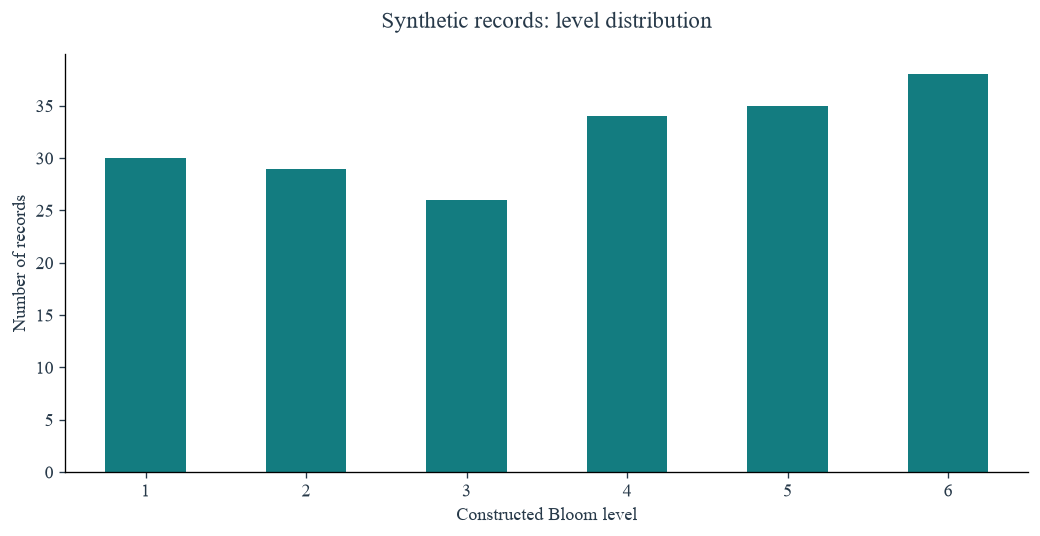

In [4]:
counts = frame.label.value_counts().reindex(range(1, 7), fill_value=0)
counts.plot.bar(color="#137c80", rot=0)
plt.xlabel("Constructed Bloom level")
plt.ylabel("Number of records")
plt.title("Synthetic records: level distribution")
plt.tight_layout()
save_figure(plt.gcf(), 'synthetic-01-01', '合成实验：检查分布', kind='synthetic', sources=['aiv/data.py', 'aiv/analysis.py', 'aiv/metrics.py'], notebook='01_数据与问题.ipynb')
plt.show()

六级分布来自固定随机种子；不能把此分布作为真实学生的能力分布。

## 计算检查
检查记录数、学生数、唯一ID及L1–L6取值。

In [5]:
assert len(frame) == 192 and frame.student.nunique() == 24
assert frame.id.is_unique
assert frame.label.between(1, 6).all()

**下一步：** [08 · 核对真实范围与来源](08_真实数据与封存记录.ipynb)